In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, r2_score
import pywt

In [2]:
from statsmodels.tools.sm_exceptions import ValueWarning
import warnings

warnings.filterwarnings("ignore", category=ValueWarning)

In [3]:
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

# Загрузка данных
df = pd.read_csv(
    'retail_sales_mock_data.csv',
    parse_dates=['Date'],
    index_col='Date'
)

df = df.sort_index()
df

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


In [4]:
# Целевая переменная
y = df['SalesAmount']

# Экзогенные переменные
exog_vars = ['Promotion', 'HolidayMonth']
X = df[exog_vars]

print(f"\nЦелевая переменная: '{y.name}'")
print(f"Экзогенные переменные: {exog_vars}")


Целевая переменная: 'SalesAmount'
Экзогенные переменные: ['Promotion', 'HolidayMonth']


In [5]:
from dataclasses import dataclass

@dataclass
class AdaptiveParams:
    period: int
    max_lags: int
    min_samples: int
    n_obs: int


def _make_odd(value: int) -> int:
    """Гарантирует нечётное число."""
    return value if value % 2 == 1 else value + 1


def get_adaptive_params(series, default_period: int = 7) -> AdaptiveParams:
    """
    Адаптивный подбор параметров для временных рядов.

    Returns:
        AdaptiveParams:
            period: сезонный период (нечётное число >= 3)
            max_lags: максимальное количество лагов для ACF
            min_samples: минимальная длина для декомпозиции
            n_obs: количество наблюдений
    """
    n_obs = len(series.dropna())

    # --- period ---
    period = _make_odd(default_period)
    period = max(3, min(period, n_obs // 2))
    period = _make_odd(period)

    # --- max_lags ---
    max_lags = max(5, min(20, n_obs // 3))

    # --- min_samples ---
    min_samples = period * 2

    return AdaptiveParams(
        period=period,
        max_lags=max_lags,
        min_samples=min_samples,
        n_obs=n_obs
    )

params = get_adaptive_params(y, default_period=7)

print("   Адаптивные параметры:")
print(f"   Наблюдений: {params.n_obs}")
print(f"   Сезонный период: {params.period} (нечётное, >= 3)")
print(f"   Макс. лагов для ACF: {params.max_lags}")
print(f"   Мин. для декомпозиции: {params.min_samples}")

   Адаптивные параметры:
   Наблюдений: 48
   Сезонный период: 7 (нечётное, >= 3)
   Макс. лагов для ACF: 16
   Мин. для декомпозиции: 14


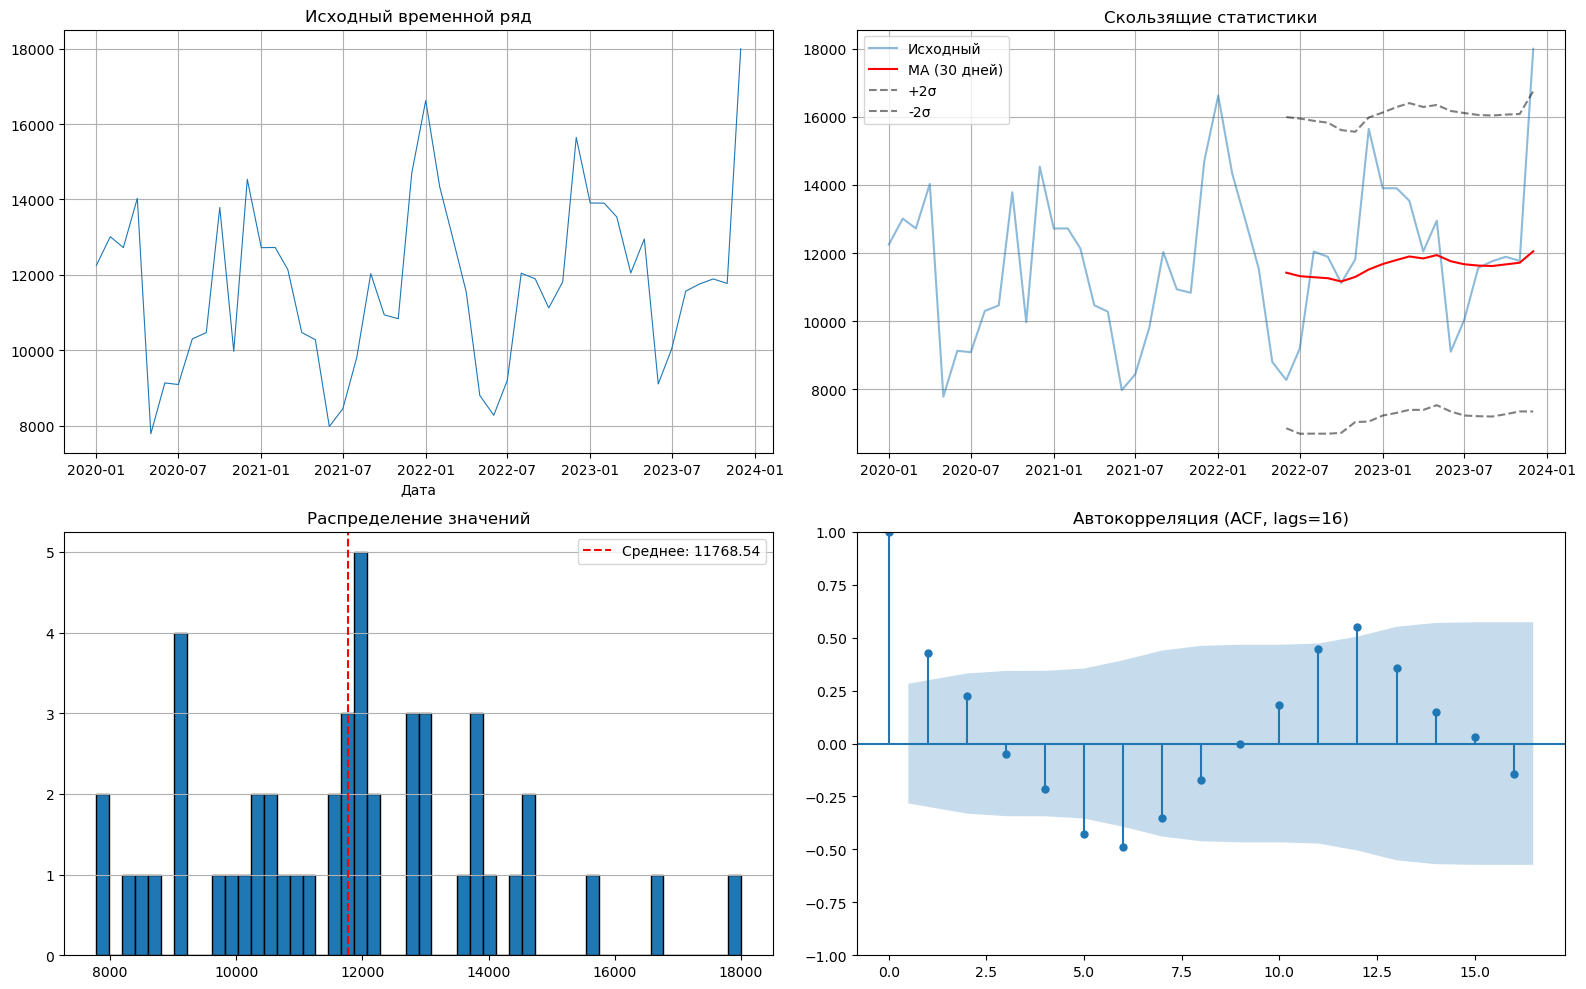

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


def _get_safe_max_lags(series_length: int, upper_bound: int = 60, lower_bound: int = 10) -> int:
    """Возвращает безопасное число лагов для ACF."""
    return max(lower_bound, min(upper_bound, series_length // 3))


def plot_eda(series, rolling_window: int = 30, hist_bins: int = 50) -> None:
    """
    Базовая визуализация временного ряда.

    Args:
        series: pandas.Series с временным рядом
        rolling_window: окно для скользящих статистик
        hist_bins: количество бинов для гистограммы
    """
    series_clean = series.dropna()

    if series_clean.empty:
        raise ValueError("Временной ряд пуст после удаления пропусков.")

    max_lags = _get_safe_max_lags(len(series_clean))
    mean_value = series_clean.mean()

    rolling_mean = series.rolling(window=rolling_window).mean()
    rolling_std = series.rolling(window=rolling_window).std()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Исходный ряд
    ax = axes[0, 0]
    ax.plot(series.index, series.values, linewidth=0.8)
    ax.set_title("Исходный временной ряд")
    ax.set_xlabel("Дата")
    ax.grid(True)

    # 2. Скользящие статистики
    ax = axes[0, 1]
    ax.plot(series.index, series.values, label="Исходный", alpha=0.5)
    ax.plot(series.index, rolling_mean, label=f"MA ({rolling_window} дней)", color="red")
    ax.plot(series.index, rolling_mean + 2 * rolling_std, "k--", alpha=0.5, label="+2σ")
    ax.plot(series.index, rolling_mean - 2 * rolling_std, "k--", alpha=0.5, label="-2σ")
    ax.set_title("Скользящие статистики")
    ax.legend()
    ax.grid(True)

    # 3. Гистограмма распределения
    ax = axes[1, 0]
    ax.hist(series_clean, bins=hist_bins, edgecolor="black")
    ax.axvline(mean_value, color="red", linestyle="--", label=f"Среднее: {mean_value:.2f}")
    ax.set_title("Распределение значений")
    ax.legend()
    ax.grid(True, axis="y")

    # 4. ACF
    ax = axes[1, 1]
    try:
        plot_acf(series_clean, lags=max_lags, ax=ax, alpha=0.05)
        ax.set_title(f"Автокорреляция (ACF, lags={max_lags})")
    except Exception as error:
        ax.text(0.5, 0.5, f"ACF plot failed\n{error}", ha="center", va="center")
        ax.set_title("Автокорреляция (ACF)")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_eda(y)

Декомпозиция: n=48, period=7, min_required=14


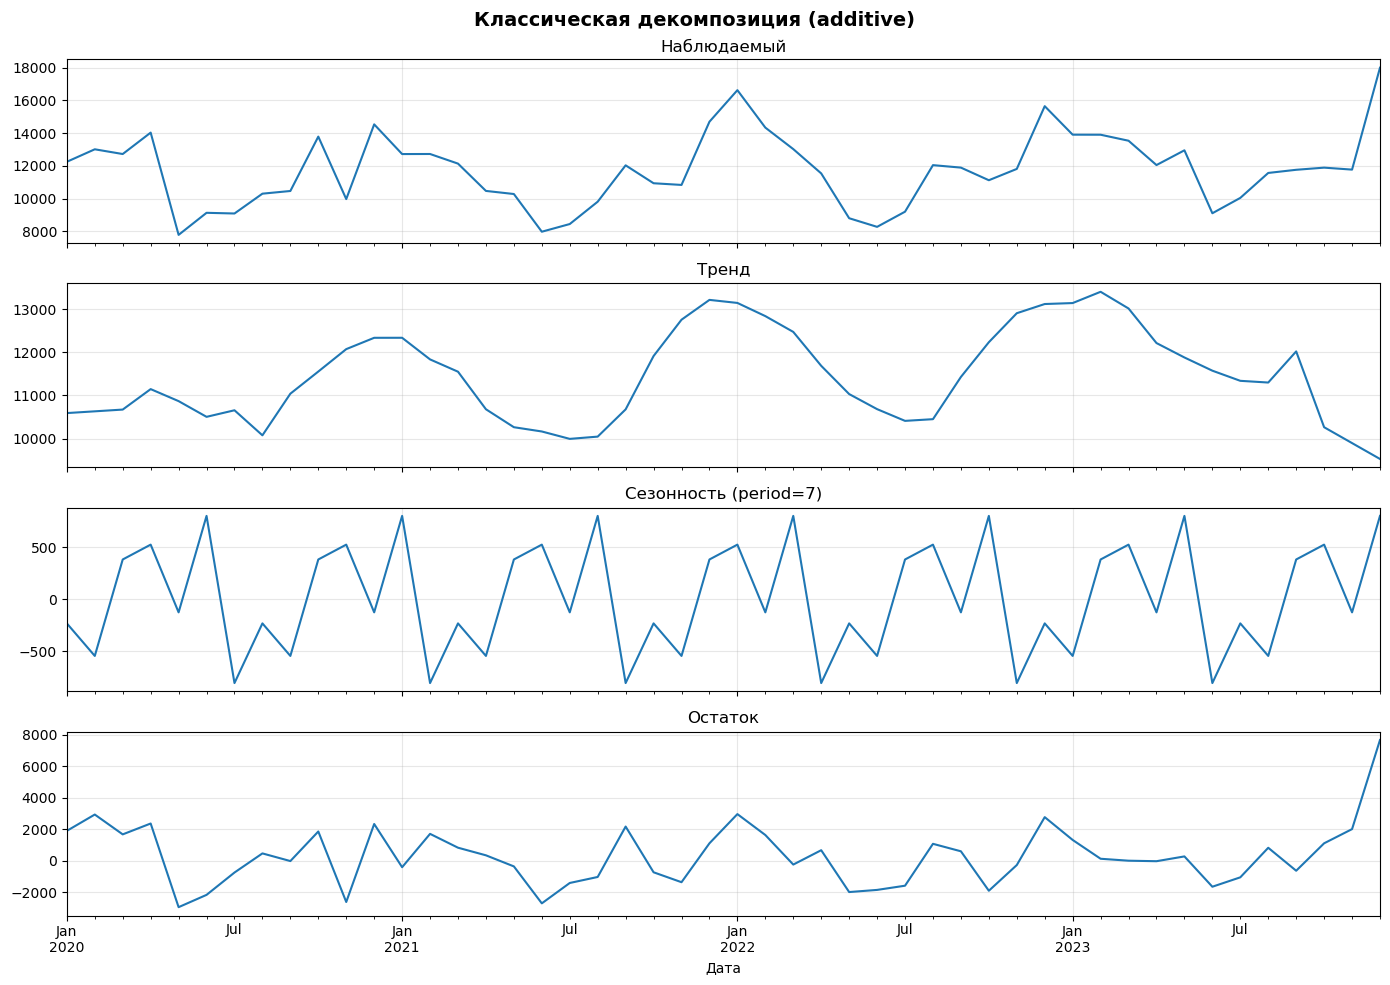

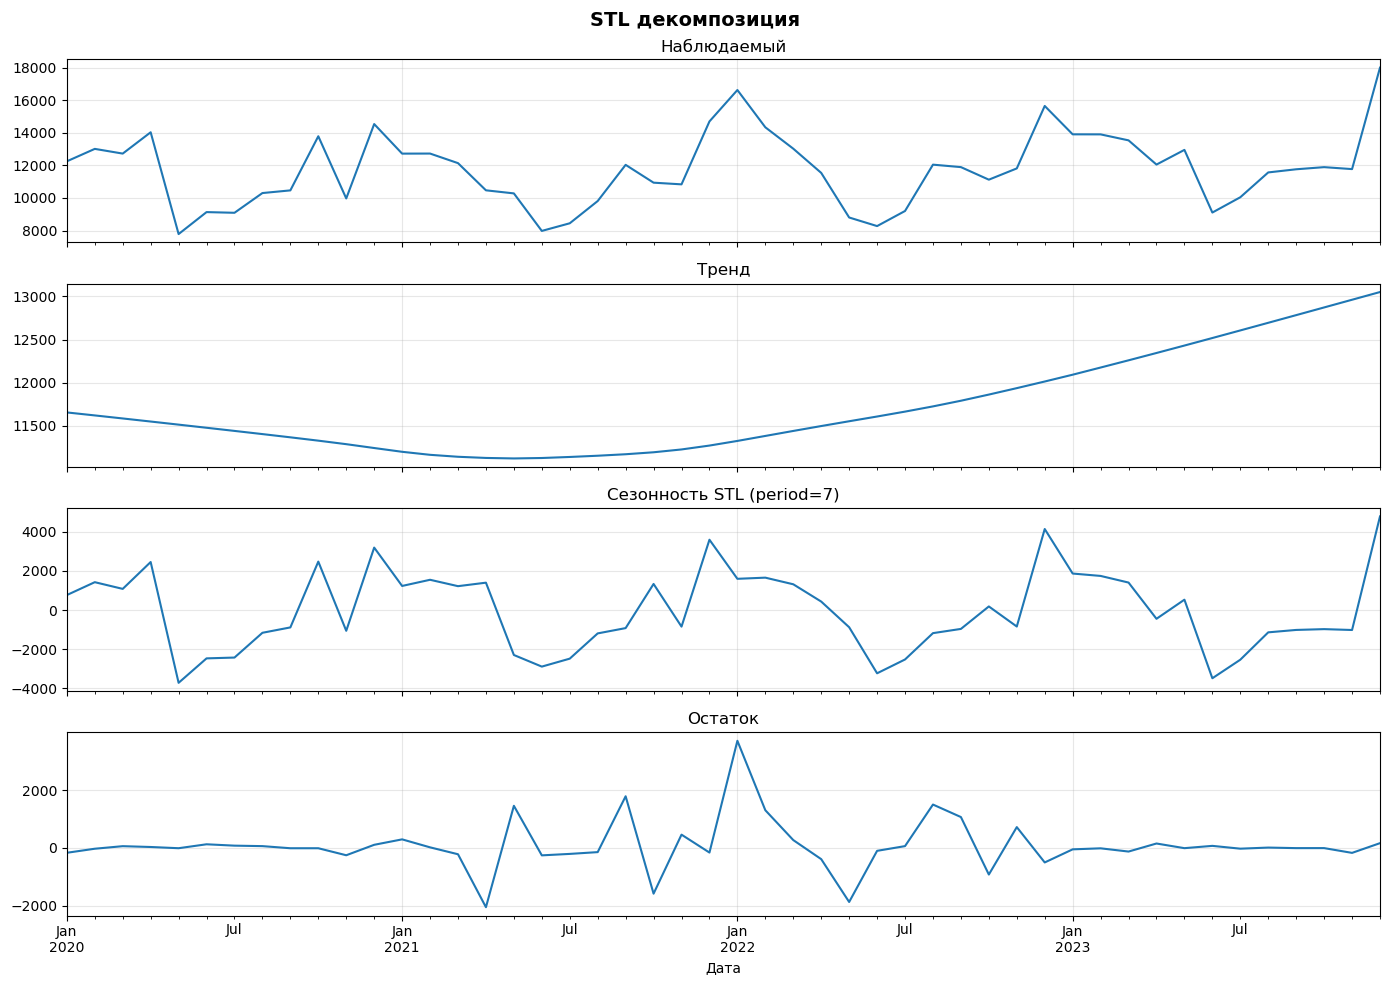

In [7]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose


def _plot_decomposition(result, title: str, seasonal_title: str) -> None:
    """Унифицированная визуализация результатов декомпозиции."""
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

    result.observed.plot(ax=axes[0], title="Наблюдаемый")
    result.trend.plot(ax=axes[1], title="Тренд")
    result.seasonal.plot(ax=axes[2], title=seasonal_title)
    result.resid.plot(ax=axes[3], title="Остаток")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Дата")
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def _safe_classic_decomposition(series, model: str, period: int):
    """Безопасный запуск классической декомпозиции."""
    return seasonal_decompose(
        series,
        model=model,
        period=period,
        extrapolate_trend="freq"
    )


def _safe_stl_decomposition(series, period: int):
    """Безопасный запуск STL-декомпозиции."""
    stl = STL(series, seasonal=period, robust=True)
    return stl.fit()


def decompose_adaptive(series, model: str = "additive", default_period: int = 7) -> dict:
    """
    Адаптивная декомпозиция временного ряда.

    Returns:
        dict:
            classic: результат seasonal_decompose или None
            stl: результат STL или None
            meta: служебная информация о параметрах
    """
    series_clean = series.dropna()

    if series_clean.empty:
        raise ValueError("Временной ряд пуст после удаления пропусков.")

    params = get_adaptive_params(series_clean, default_period=default_period)

    print(
        f"Декомпозиция: n={params.n_obs}, "
        f"period={params.period}, "
        f"min_required={params.min_samples}"
    )

    if params.n_obs < params.min_samples:
        print(
            f"Предупреждение: {params.n_obs} < {params.min_samples} — "
            "декомпозиция может быть неточной"
        )
        print("Рекомендация: соберите больше данных или используйте упрощённый анализ")

    results = {
        "classic": None,
        "stl": None,
        "meta": {
            "n_obs": params.n_obs,
            "period": params.period,
            "min_samples": params.min_samples,
            "model": model,
        },
    }

    # Классическая декомпозиция
    try:
        classic_result = _safe_classic_decomposition(
            series=series_clean,
            model=model,
            period=params.period
        )
        results["classic"] = classic_result

        _plot_decomposition(
            classic_result,
            title=f"Классическая декомпозиция ({model})",
            seasonal_title=f"Сезонность (period={params.period})"
        )

    except Exception as error:
        print(f"Классическая декомпозиция не выполнена: {error}")

    # STL декомпозиция
    try:
        stl_result = _safe_stl_decomposition(
            series=series_clean,
            period=params.period
        )
        results["stl"] = stl_result

        _plot_decomposition(
            stl_result,
            title="STL декомпозиция",
            seasonal_title=f"Сезонность STL (period={params.period})"
        )

    except Exception as error:
        print(f"STL декомпозиция не выполнена: {error}")

    return results


decomp_results = decompose_adaptive(y, model="additive", default_period=7)

# Декомпозиция временного ряда (аддитивная модель)

## Наблюдаемый ряд
- **Период анализа:** январь 2020 — 2023 (3 года)
- **Диапазон значений:** 8000–18000 единиц
- **Динамика:** наблюдаются выраженные регулярные колебания с чередованием пиков и спадов

## Трендовая компонента
- **Тип тренда:** нелинейный, с выраженной цикличностью
- **Диапазон:** 10000–13500 единиц
- **Динамика по годам:**
  - **2020:** стабильный уровень (~10500–11000)
  - **2021:** рост со второй половины года, максимум ~12500
  - **2022:** ярко выраженный пик в январе (~13500) с последующим снижением
  - **2023:** повторение аналогичного паттерна с пиком в начале года
- **Вывод:** тренд демонстрирует устойчивую годовую цикличность

## Сезонная компонента (period = 7)
- **Тип:** недельная сезонность (период 7 дней)
- **Амплитуда:** ±500 единиц
- **Относительный вклад:** около 4.2% от среднего уровня
- **Характер:** стабильные внутринедельные колебания
- **Вывод:** сезонность присутствует, но её влияние умеренное

## Остаточная компонента
- **Диапазон:** от -2000 до +8000 единиц
- **Особенности:**
  - присутствуют выбросы (особенно в конце 2023 года)
  - дисперсия не является стационарной
  - наблюдаются структуры, не объяснённые трендом и сезонностью
- **Вывод:** остатки не являются белым шумом → требуется дополнительное моделирование

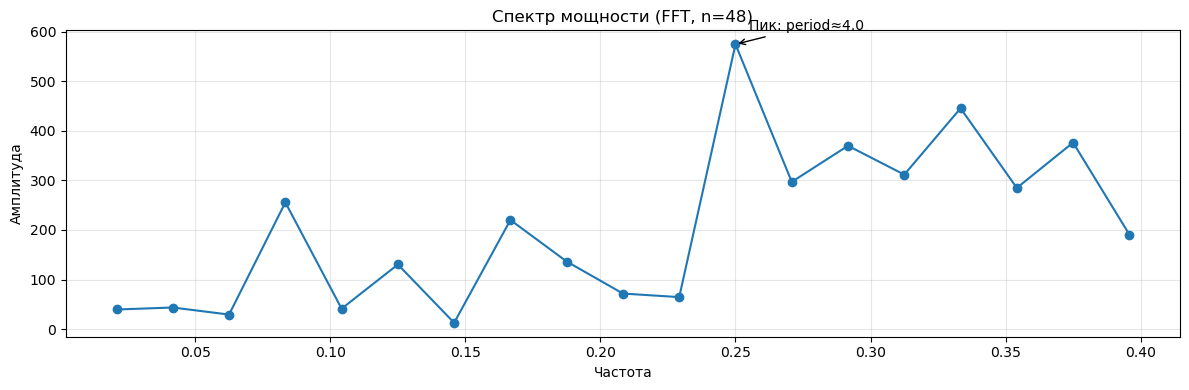

FFT завершён. Доминирующий период: ~4.0


In [8]:
def spectral_analysis_simple(series):
    """Упрощённый спектральный анализ для малых выборок"""
    series_clean = series.dropna()
    n = len(series_clean)

    if n < 16:
        print(f"FFT требует минимум 16 наблюдений, есть: {n}")
        return None

    # Детрендирование
    detrended = series_clean - series_clean.rolling(window=3, center=True, min_periods=1).mean()
    detrended = detrended.dropna()

    if len(detrended) < 16:
        print("Недостаточно данных после детрендирования")
        return None

    # FFT
    yf = fft(detrended.values)
    xf = fftfreq(len(detrended), d=1)[:len(detrended)//2]
    amplitude = 2.0/len(detrended) * np.abs(yf[0:len(detrended)//2])

    # Визуализация
    plt.figure(figsize=(12, 4))
    plt.plot(xf[1:20], amplitude[1:20], marker='o')
    plt.xlabel('Частота')
    plt.ylabel('Амплитуда')
    plt.title(f'Спектр мощности (FFT, n={len(detrended)})')
    plt.grid(True, alpha=0.3)

    # Подпись доминирующей частоты
    if len(amplitude) > 2:
        idx = np.argmax(amplitude[1:15]) + 1
        freq = xf[idx]
        period = 1/freq if freq > 0 else np.inf
        plt.annotate(f'Пик: period≈{period:.1f}',
                    xy=(xf[idx], amplitude[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->'))

    plt.tight_layout()
    plt.show()

    print(f"FFT завершён. Доминирующий период: ~{period:.1f}")
    return xf, amplitude

fft_result = spectral_analysis_simple(y)

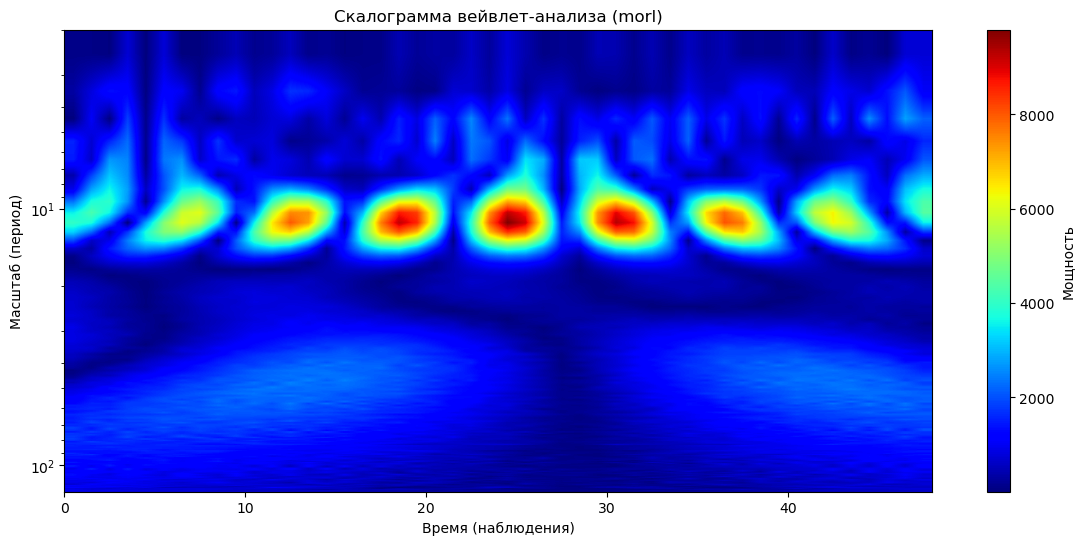

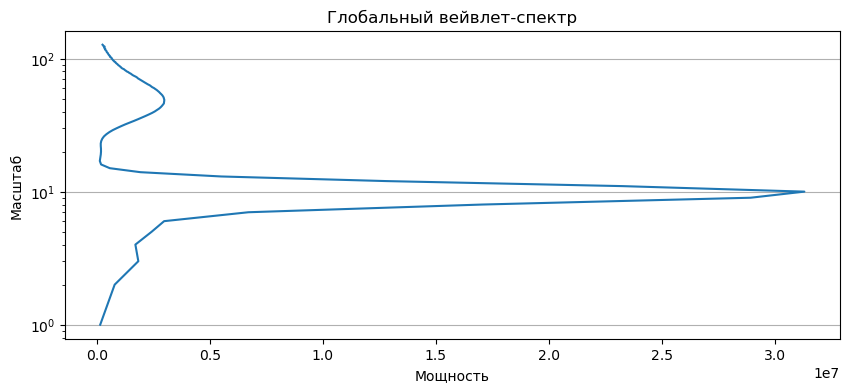

Доминирующий масштаб вейвлета: ~10.0


In [9]:
def wavelet_analysis(series, wavelet='morl', scales=None):
    """Вейвлет-анализ с визуализацией скалограммы"""
    data = series.values - np.mean(series.values)
    if scales is None:
        scales = np.arange(1, 128)

    coefficients, frequencies = pywt.cwt(data, scales, wavelet, sampling_period=1)

    plt.figure(figsize=(14, 6))
    plt.imshow(np.abs(coefficients), extent=[0, len(data), scales[-1], scales[1]],
               cmap='jet', aspect='auto', interpolation='bilinear')
    plt.colorbar(label='Мощность')
    plt.ylabel('Масштаб (период)')
    plt.xlabel('Время (наблюдения)')
    plt.title(f'Скалограмма вейвлет-анализа ({wavelet})')
    plt.yscale('log')
    plt.show()

    global_wavelet = np.mean(np.abs(coefficients)**2, axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(global_wavelet, scales)
    plt.xlabel('Мощность')
    plt.ylabel('Масштаб')
    plt.title('Глобальный вейвлет-спектр')
    plt.yscale('log')
    plt.grid(True, axis='y')
    plt.show()

    dominant_scale = scales[np.argmax(global_wavelet)]
    print(f"Доминирующий масштаб вейвлета: ~{dominant_scale:.1f}")
    return coefficients, frequencies, dominant_scale

coeffs, freqs, scale_wavelet = wavelet_analysis(y, wavelet='morl')

# Вейвлет-анализ

## Ключевые результаты
- **Доминирующий масштаб:** ~10 наблюдений (мощность ~3×10⁷)
- **Нестационарность:** периодичность носит импульсный характер и проявляется неравномерно во времени
- **Интервалы между пиками:** варьируются в диапазоне 7–10 наблюдений

## Сравнение методов оценки сезонности
- **STL:** period = 7 — фиксированная недельная сезонность
- **FFT:** period = 4 — усреднённая частотная оценка
- **Вейвлет-анализ:** period ≈ 10 — отражает реальную, нестационарную структуру

## Практическая интерпретация
- В контексте retail-данных динамика определяется внешними факторами (промоакции, праздники)
- Сезонность не является строго регулярной
- Использование моделей с фиксированным периодом ограничено

## Рекомендации по моделированию
- Применять **SARIMAX** с включением экзогенных переменных
- Рассматривать сезонный параметр:
  - либо **s = 10**
  - либо диапазон **[7–10]** в рамках подбора гиперпараметров

In [10]:
train_size = int(len(y) * 0.8)
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

print(f"Train: {len(y_train)}, Test: {len(y_test)}")

def check_adf(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{name}:")
    print(f"  ADF: {result[0]:.4f}, p-value: {result[1]:.4f}")
    print(f"  {'Стационарен' if result[1] < 0.05 else 'Нестационарен'}")

check_adf(y_train, "Train")
check_adf(y_train.diff().dropna(), "Train (1st diff)")

Train: 38, Test: 10

Train:
  ADF: -3.7677, p-value: 0.0033
  Стационарен

Train (1st diff):
  ADF: -4.3390, p-value: 0.0004
  Стационарен


Наблюдений после дифференцирования: 37
Лагов для ACF/PACF: 12


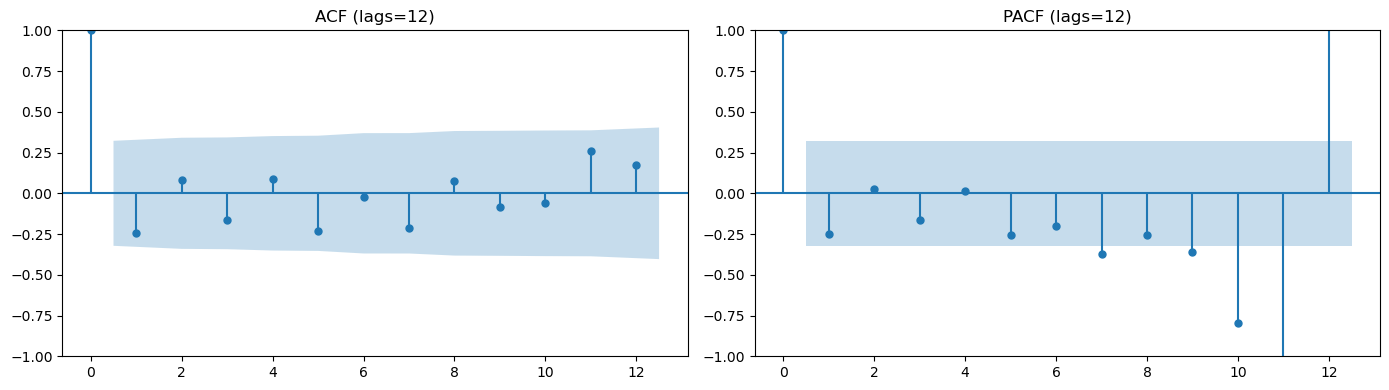

In [11]:
n_diff = len(y_train.diff().dropna())
max_lags = min(15, n_diff // 3)
max_lags = max(max_lags, 5)

print(f"Наблюдений после дифференцирования: {n_diff}")
print(f"Лагов для ACF/PACF: {max_lags}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

try:
    plot_acf(y_train.diff().dropna(), lags=max_lags, ax=axes[0], alpha=0.05)
    axes[0].set_title(f'ACF (lags={max_lags})')
except Exception as e:
    print(f"ACF error: {e}")
    axes[0].text(0.5, 0.5, 'ACF error', ha='center', va='center')

try:
    plot_pacf(y_train.diff().dropna(), lags=max_lags, ax=axes[1], alpha=0.05, method='yw')
    axes[1].set_title(f'PACF (lags={max_lags})')
except Exception as e:
    print(f"PACF error: {e}")
    axes[1].text(0.5, 0.5, 'PACF error', ha='center', va='center')

plt.tight_layout()
plt.show()

In [12]:
# ARIMA
print("ARIMA(1,1,1)...")
arima_model = ARIMA(y_train, order=(1,1,1))
arima_fit = arima_model.fit()
print(f"ARIMA: AIC={arima_fit.aic:.2f}")

# SARIMAX (с экзогенными)
print("SARIMAX с exog...")
try:
    sarimax_model = SARIMAX(
        y_train,
        exog=X_train,
        order=(1,1,1),
        seasonal_order=(1,0,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarimax_fit = sarimax_model.fit(disp=False)
    print(f"SARIMAX: AIC={sarimax_fit.aic:.2f}")
except Exception as e:
    print(f"SARIMAX error: {e}")
    sarimax_fit = None

ARIMA(1,1,1)...
ARIMA: AIC=678.59
SARIMAX с exog...
SARIMAX: AIC=493.77


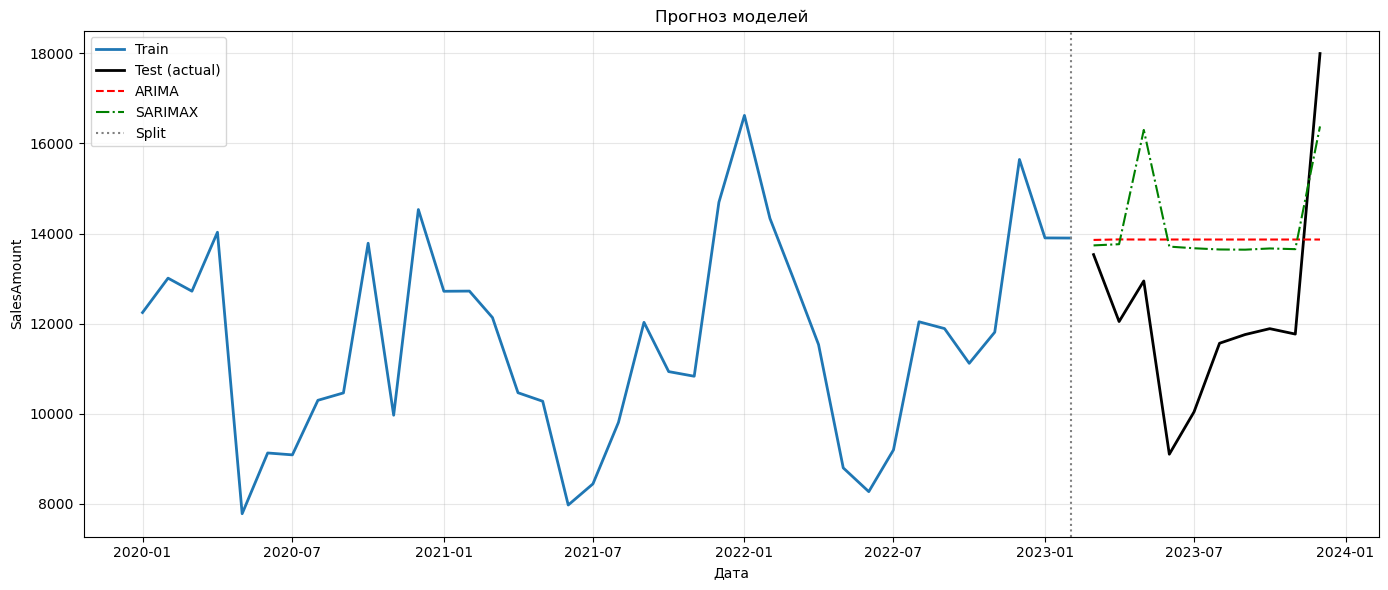

In [13]:
arima_forecast = arima_fit.forecast(steps=len(y_test))

if sarimax_fit is not None:
    sarimax_forecast = sarimax_fit.forecast(steps=len(y_test), exog=X_test)
else:
    sarimax_forecast = arima_forecast

# Визуализация прогноза
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Train', linewidth=2)
plt.plot(y_test.index, y_test, label='Test (actual)', color='black', linewidth=2)
plt.plot(y_test.index, arima_forecast, label='ARIMA', linestyle='--', color='red')
if sarimax_fit is not None:
    plt.plot(y_test.index, sarimax_forecast, label='SARIMAX', linestyle='-.', color='green')
plt.axvline(x=y_train.index[-1], color='gray', linestyle=':', label='Split')
plt.title('Прогноз моделей')
plt.xlabel('Дата')
plt.ylabel('SalesAmount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


def calc_metrics(actual, pred, model_name: str) -> dict:
    """Расчёт метрик качества модели."""
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, pred)

    metrics = {
        "model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
    }

    print(f"\n{model_name}:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    return metrics


def build_results_table(models_info: list) -> pd.DataFrame:
    """Формирование итоговой таблицы по моделям."""
    rows = []

    for info in models_info:
        row = {
            "Модель": info["name"],
            "AIC": info["fit"].aic,
            "BIC": info["fit"].bic,
            "R²": info["metrics"]["R2"],
            "RMSE": info["metrics"]["RMSE"],
        }
        rows.append(row)

    return pd.DataFrame(rows).round(4)


# --- расчёт метрик ---
models_info = []

metrics_arima = calc_metrics(y_test, arima_forecast, "ARIMA")
models_info.append({
    "name": "ARIMA",
    "fit": arima_fit,
    "metrics": metrics_arima
})

if sarimax_fit is not None:
    metrics_sarimax = calc_metrics(y_test, sarimax_forecast, "SARIMAX")
    models_info.append({
        "name": "SARIMAX",
        "fit": sarimax_fit,
        "metrics": metrics_sarimax
    })


# --- итоговая таблица ---
print("\n" + "=" * 60)
print("ИТОГОВАЯ ТАБЛИЦА")
print("=" * 60)

results = build_results_table(models_info)
print(results.to_markdown(index=False))


ARIMA:
  MSE:  7671901.4594
  RMSE: 2769.8198
  R²:   -0.5033

SARIMAX:
  MSE:  6586371.2311
  RMSE: 2566.3926
  R²:   -0.2906

ИТОГОВАЯ ТАБЛИЦА
| Модель   |     AIC |     BIC |      R² |    RMSE |
|:---------|--------:|--------:|--------:|--------:|
| ARIMA    | 678.586 | 683.419 | -0.5033 | 2769.82 |
| SARIMAX  | 493.771 | 503.096 | -0.2906 | 2566.39 |
